In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_excel("/content/Copy of Online Retail.xlsx")

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
((df['InvoiceNo'].astype(str).str.contains('C', na=False)) & (df['Quantity'] < 0)).sum()

np.int64(9288)

In [ ]:
df[df['InvoiceNo']==0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [ ]:
((~df['InvoiceNo'].astype(str).str.contains('C', na=False)) & (df['Quantity'] < 0)).sum()

np.int64(1336)

In [ ]:
df[(~df['InvoiceNo'].astype(str).str.contains('C', na=False)) & (df['Quantity'] < 0)].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [ ]:
((~df['InvoiceNo'].astype(str).str.contains('C', na=False)) &
 (df['Quantity'] < 0) &
 (df['UnitPrice'] == 0)).sum()

np.int64(1336)

In [ ]:
((~df['InvoiceNo'].astype(str).str.contains('C', na=False)) &
 (df['Quantity'] < 0) &
 (df['UnitPrice'] == 0) &
 (df['CustomerID'].isna())).sum()

np.int64(1336)

In [ ]:
((~df['InvoiceNo'].astype(str).str.contains('C', na=False)) &
 (df['Quantity'] < 0) &
 (df['UnitPrice'] == 0) &
 (df['CustomerID'].isna()) &
 (df['Description'].isna())).sum()

np.int64(862)

In [ ]:
1336 / len(df) * 100

0.24653585749636933

In [ ]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df[df['Quantity'] < 0]['Sales'].sum()

np.float64(-896812.49)

In [ ]:
df[df['Quantity'] > 0]['Sales'].sum()

np.float64(10644560.424)

In [ ]:
df['Sales'].sum()

np.float64(9747747.933999998)

In [ ]:
df[df['Quantity'] < 0].groupby('Country')['Sales'].sum().sort_values()

,Sales
Country,
United Kingdom,-815291.60
EIRE,-20177.14
France,-12311.21
Singapore,-12158.90
Germany,-7168.93
Spain,-6802.53
Hong Kong,-5574.76
Portugal,-4380.08
Japan,-2075.75


In [ ]:
df[(df['Quantity'] < 0) & (df['Country'] == 'United Kingdom')].groupby('Description')['Sales'].sum().sort_values().head(10)

,Sales
Description,
AMAZON FEE,-235281.59
"PAPER CRAFT , LITTLE BIRDIE",-168469.60
Manual,-100432.34
MEDIUM CERAMIC TOP STORAGE JAR,-77446.31
POSTAGE,-10315.51
CRUK Commission,-7933.43
REGENCY CAKESTAND 3 TIER,-7867.35
Bank Charges,-7340.64
FAIRY CAKE FLANNEL ASSORTED COLOUR,-6591.42


In [ ]:
df[df['Description'] == 'AMAZON FEE'][['InvoiceNo', 'Quantity', 'UnitPrice', 'Sales', 'CustomerID', 'Country']].head(10)

,InvoiceNo,Quantity,UnitPrice,Sales,CustomerID,Country
14514,C537600,-1,1.00,-1.00,NaN,United Kingdom
15016,C537630,-1,13541.33,-13541.33,NaN,United Kingdom
15017,537632,1,13541.33,13541.33,NaN,United Kingdom
16232,C537644,-1,13474.79,-13474.79,NaN,United Kingdom
16313,C537647,-1,5519.25,-5519.25,NaN,United Kingdom
16356,C537651,-1,13541.33,-13541.33,NaN,United Kingdom
16357,C537652,-1,6706.71,-6706.71,NaN,United Kingdom
43702,C540117,-1,16888.02,-16888.02,NaN,United Kingdom
43703,C540118,-1,16453.71,-16453.71,NaN,United Kingdom
96844,C544587,-1,5575.28,-5575.28,NaN,United Kingdom


In [ ]:
df[(df['Quantity'] < 0) & (df['Country'] == 'United Kingdom') & (df['Description'] == 'AMAZON FEE')]['Sales'].sum()

np.float64(-235281.59)

In [ ]:
df[(df['Quantity'] < 0) & (df['Country'] == 'United Kingdom') &
 (df['Description'] == 'PAPER CRAFT, LITTLE BIRDIE')]['Sales'].sum()

np.float64(0.0)

In [ ]:
df[(df['Quantity'] < 0) &
   (df['Country'] == 'United Kingdom') &
   (df['Description'] == 'Manual')][
    ['InvoiceNo', 'Quantity', 'UnitPrice', 'Sales', 'CustomerID']].head(10)

,InvoiceNo,Quantity,UnitPrice,Sales,CustomerID
14716,C537610,-1,631.31,-631.31,NaN
14728,C537613,-1,313.78,-313.78,NaN
21758,C538124,-4,0.50,-2.00,15329.0
23241,C538189,-1,133.08,-133.08,NaN
28993,C538681,-1,316.30,-316.30,NaN
28994,C538682,-1,1130.90,-1130.90,NaN
29530,C538806,-1,4.25,-4.25,15181.0
45509,C540266,-1,458.29,-458.29,NaN
45913,C540307,-2,21.95,-43.90,15823.0
59410,C541284,-36,0.87,-31.32,17744.0


In [ ]:
df[df['Description'].str.contains('FEE|POSTAGE|COMMISSION|CHARGE|MANUAL',case=False,na=False)]['Description'].value_counts()

,count
Description,
POSTAGE,1252
DOTCOM POSTAGE,709
Manual,572
SET OF TEA COFFEE SUGAR TINS PANTRY,509
"SET 3 RETROSPOT TEA,COFFEE,SUGAR",449
LONDON BUS COFFEE MUG,328
QUEENS GUARD COFFEE MUG,279
COFFEE MUG APPLES DESIGN,273
COFFEE MUG CAT + BIRD DESIGN,270


In [ ]:
df[df['Description'].isin([
    'AMAZON FEE',
    'POSTAGE',
    'DOTCOM POSTAGE',
    'Manual',
    'CRUK Commission',
    'Bank Charges'
])]['Description'].value_counts()

,count
Description,
POSTAGE,1252
DOTCOM POSTAGE,709
Manual,572
Bank Charges,37
AMAZON FEE,34
CRUK Commission,16


In [ ]:
admin_categories = [
    'AMAZON FEE',
    'POSTAGE',
    'DOTCOM POSTAGE',
    'Manual',
    'CRUK Commission',
    'Bank Charges'
]

df[
    (df['Quantity'] < 0) &
    (df['Description'].isin(admin_categories))
].groupby('Description')['Sales'].sum().sort_values()

,Sales
Description,
AMAZON FEE,-235281.59
Manual,-146784.46
POSTAGE,-11871.24
CRUK Commission,-7933.43
Bank Charges,-7340.64
DOTCOM POSTAGE,-3.29


In [ ]:
admin_sales = df[
    (df['Quantity'] < 0) &
    (df['Description'].isin(admin_categories))
]['Sales'].sum()

admin_sales / df[df['Quantity'] < 0]['Sales'].sum() * 100

np.float64(45.62990085028812)

In [ ]:
product_negative_sales = df[
    (df['Quantity'] < 0) &
    (~df['Description'].isin(admin_categories))
]['Sales'].sum()

product_negative_sales

np.float64(-487597.83999999997)

In [ ]:
df[
    (df['Quantity'] < 0) &
    (~df['Description'].isin(admin_categories))
].groupby('Description')['Sales'].sum().sort_values().head(15)

,Sales
Description,
"PAPER CRAFT , LITTLE BIRDIE",-168469.60
MEDIUM CERAMIC TOP STORAGE JAR,-77479.64
REGENCY CAKESTAND 3 TIER,-9722.55
WHITE HANGING HEART T-LIGHT HOLDER,-6624.30
FAIRY CAKE FLANNEL ASSORTED COLOUR,-6591.42
Discount,-5696.22
PANTRY CHOPPING BOARD,-4803.06
DOORMAT FAIRY CAKE,-4554.90
GIN + TONIC DIET METAL SIGN,-3775.33


In [ ]:
df[
    (df['Description'] == 'PAPER CRAFT, LITTLE BIRDIE') &
    (df['Quantity'] < 0)
][['InvoiceNo', 'Quantity', 'UnitPrice', 'Sales', 'CustomerID', 'Country']].head(15)

,InvoiceNo,Quantity,UnitPrice,Sales,CustomerID,Country


In [ ]:
df[
    (df['Description'] == 'PAPER CRAFT, LITTLE BIRDIE')
].shape

(0, 9)

In [ ]:
df[df['Description'].astype(str).str.contains(
    'PAPER CRAFT, LITTLE BIRDIE',
    case=False,
    na=False
)]['Description'].unique()

array([], dtype=object)

In [ ]:
df[df['Description'].astype(str).str.contains(
    'PAPER',
    case=False,
    na=False
)]['Description'].value_counts().head(20)

,count
Description,
PAPER CHAIN KIT 50'S CHRISTMAS,1210
SET/20 RED RETROSPOT PAPER NAPKINS,1015
PAPER CHAIN KIT VINTAGE CHRISTMAS,850
PAPER BUNTING RETROSPOT,812
PAPER CHAIN KIT RETROSPOT,619
SET/6 RED SPOTTY PAPER PLATES,532
SET OF 72 PINK HEART PAPER DOILIES,514
SET OF 72 RETROSPOT PAPER DOILIES,462
PAPER CHAIN KIT EMPIRE,448


In [ ]:
df[
    (df['Quantity'] < 0) &
    (~df['Description'].isin(admin_categories))
].groupby('Description')['Sales'].sum().sort_values().head(10)

,Sales
Description,
"PAPER CRAFT , LITTLE BIRDIE",-168469.60
MEDIUM CERAMIC TOP STORAGE JAR,-77479.64
REGENCY CAKESTAND 3 TIER,-9722.55
WHITE HANGING HEART T-LIGHT HOLDER,-6624.30
FAIRY CAKE FLANNEL ASSORTED COLOUR,-6591.42
Discount,-5696.22
PANTRY CHOPPING BOARD,-4803.06
DOORMAT FAIRY CAKE,-4554.90
GIN + TONIC DIET METAL SIGN,-3775.33


In [ ]:
df[df['Description'] == 'PAPER CRAFT , LITTLE BIRDIE']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,-168469.6


In [ ]:
df[(df['Description'] == 'PAPER CRAFT , LITTLE BIRDIE') & (df['Quantity'] > 0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6


In [ ]:
df[df['Quantity'] < 0]['Quantity'].abs().describe()

,Quantity
count,10624.000000
mean,45.607210
std,1092.214216
min,1.000000
25%,1.000000
50%,2.000000
75%,10.000000
max,80995.000000


In [ ]:
df[df['Quantity'] < -1000]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,15838.0,United Kingdom,-280.80
50849,540564,22617,"mouldy, thrown away.",-2600,2011-01-10 10:36:00,0.00,NaN,United Kingdom,-0.00
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.60
65063,541685,22351,Given away,-1400,2011-01-20 15:41:00,0.00,NaN,United Kingdom,-0.00
82794,543257,84611B,thrown away,-1430,2011-02-04 16:06:00,0.00,NaN,United Kingdom,-0.00
113580,545990,84598,check,-3000,2011-03-08 13:07:00,0.00,NaN,United Kingdom,-0.00
114539,546024,85175,? sold as sets?,-1200,2011-03-08 17:31:00,0.00,NaN,United Kingdom,-0.00
115488,546124,35610C,Thrown away.,-1121,2011-03-09 14:50:00,0.00,NaN,United Kingdom,-0.00
115505,546130,35610A,thrown away,-1277,2011-03-09 15:08:00,0.00,NaN,United Kingdom,-0.00
115810,546142,40016,damaged stock,-1100,2011-03-09 16:37:00,0.00,NaN,United Kingdom,-0.00


In [ ]:
df[df['Quantity'] < -1000]['Sales']

,Sales
4287,-280.80
50849,-0.00
61624,-77183.60
65063,-0.00
82794,-0.00
113580,-0.00
114539,-0.00
115488,-0.00
115505,-0.00
115810,-0.00


In [ ]:
df[df['Quantity'] < -1000]['Sales'].count()

np.int64(58)

In [ ]:
df[df['Quantity'] < -1000].groupby('Description').size().sort_values(ascending=False)

,0
Description,
"Unsaleable, destroyed.",6
Damaged,5
thrown away,2
damages wax,2
check,2
PINK BLUE FELT CRAFT TRINKET BOX,2
printing smudges/thrown away,2
incorrect stock entry.,2
GIN + TONIC DIET METAL SIGN,1


In [ ]:
extreme = df[df['Quantity'] < -1000]

wastage_keywords = 'damaged|destroyed|unsaleable|thrown away|throw away'

wastage_rows = extreme[
    extreme['Description'].str.contains(
        wastage_keywords,
        case=False,
        na=False
    )
]

wastage_rows.shape[0]

23

In [ ]:
wastage_rows['Sales'].sum()

np.float64(0.0)

In [ ]:
extreme.groupby('Description')['Sales'].sum().sort_values()

,Sales
Description,
"PAPER CRAFT , LITTLE BIRDIE",-168469.60
MEDIUM CERAMIC TOP STORAGE JAR,-77183.60
FAIRY CAKE FLANNEL ASSORTED COLOUR,-6539.40
WHITE HANGING HEART T-LIGHT HOLDER,-4921.50
GIN + TONIC DIET METAL SIGN,-3700.00
TEA TIME PARTY BUNTING,-3315.00
PINK BLUE FELT CRAFT TRINKET BOX,-2747.52
HERB MARKER BASIL,-833.25
ROTATING SILVER ANGELS T-LIGHT HLDR,-280.80


In [ ]:
df.groupby("CustomerID")["Sales"].sum().sort_values(ascending=False).head(10)

,Sales
CustomerID,
14646.0,279489.02
18102.0,256438.49
17450.0,187482.17
14911.0,132572.62
12415.0,123725.45
14156.0,113384.14
17511.0,88125.38
16684.0,65892.08
13694.0,62653.10


In [ ]:
top_10_sales = df.groupby("CustomerID")["Sales"].sum().sort_values(ascending=False).head(10).sum()

total_sales = df["Sales"].sum()

top_10_percentage = (top_10_sales / total_sales) * 100

top_10_percentage

np.float64(14.04613454585048)

In [ ]:
df.groupby("StockCode")["Sales"].sum().sort_values(ascending=False).head(10)

,Sales
StockCode,
DOT,206245.48
22423,164762.19
47566,98302.98
85123A,97894.50
85099B,92356.03
23084,66756.59
POST,66230.64
22086,63791.94
84879,58959.73


In [ ]:
top_10_products = df.groupby("StockCode")["Sales"].sum().sort_values(ascending=False).head(10).sum()

total_products = df["Sales"].sum()

top_10_percentage = (top_10_products / total_products) * 100

top_10_percentage

np.float64(9.941456699140783)

In [ ]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = (
    df.groupby('Month')['Sales']
      .sum()
      .sort_index()
)

monthly_sales

,Sales
Month,
2010-12,748957.020
2011-01,560000.260
2011-02,498062.650
2011-03,683267.080
2011-04,493207.121
2011-05,723333.510
2011-06,691123.120
2011-07,681300.111
2011-08,682680.510


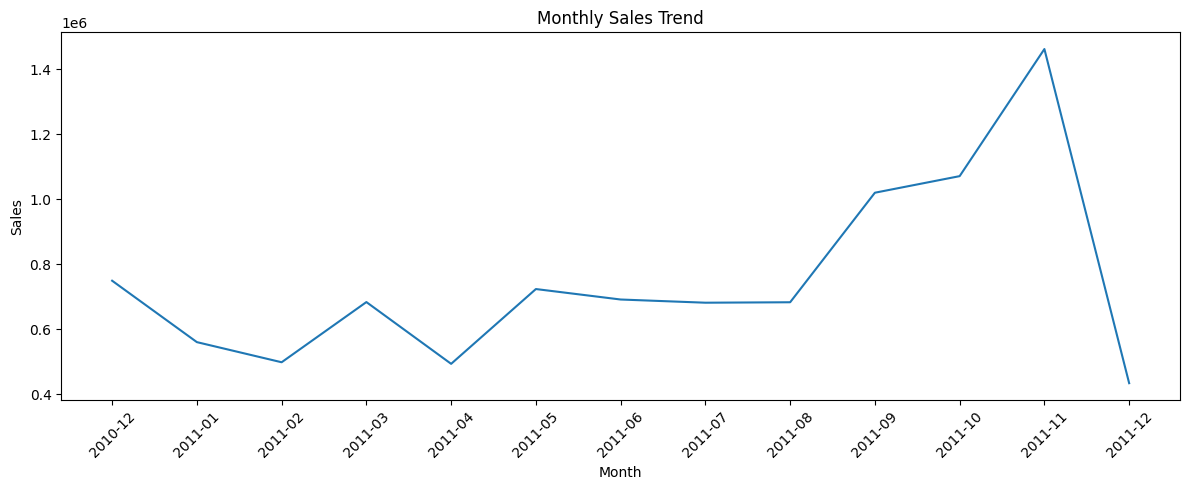

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.show()

In [ ]:
november_sales = df[
    (df['InvoiceDate'].dt.year == 2011) &
    (df['InvoiceDate'].dt.month == 11)
]

november_top_products = (
    november_sales.groupby('StockCode')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

november_top_products

,Sales
StockCode,
DOT,36905.40
23084,34422.09
22086,28883.04
85123A,14119.80
22197,13968.74
22910,12831.54
22423,12798.48
23355,11500.87
79321,11475.07


In [ ]:
november_top_descriptions = (
    november_sales[november_sales['StockCode'].isin(november_top_products.index)]
    .groupby('StockCode')['Description']
    .first()
)

november_top_descriptions

,Description
StockCode,
22086,PAPER CHAIN KIT 50'S CHRISTMAS
22197,POPCORN HOLDER
22423,REGENCY CAKESTAND 3 TIER
22910,PAPER CHAIN KIT VINTAGE CHRISTMAS
23084,RABBIT NIGHT LIGHT
23355,HOT WATER BOTTLE KEEP CALM
79321,CHILLI LIGHTS
85099B,JUMBO BAG RED RETROSPOT
85123A,WHITE HANGING HEART T-LIGHT HOLDER


In [ ]:
dot_sales = november_sales[november_sales['StockCode'] == 'DOT']['Sales'].sum()

november_total_sales = november_sales['Sales'].sum()

dot_percentage = (dot_sales / november_total_sales) * 100

dot_percentage

np.float64(2.5247300977847704)

In [ ]:
monthly_change = monthly_sales.diff()

monthly_change

,Sales
Month,
2010-12,NaN
2011-01,-188956.760
2011-02,-61937.610
2011-03,185204.430
2011-04,-190059.959
2011-05,230126.389
2011-06,-32210.390
2011-07,-9823.009
2011-08,1380.399


In [ ]:
top_10_november_sales = november_top_products.sum()

november_total_sales = november_sales['Sales'].sum()

top_10_november_percentage = (
    top_10_november_sales / november_total_sales
) * 100

top_10_november_percentage

np.float64(12.88609096078775)

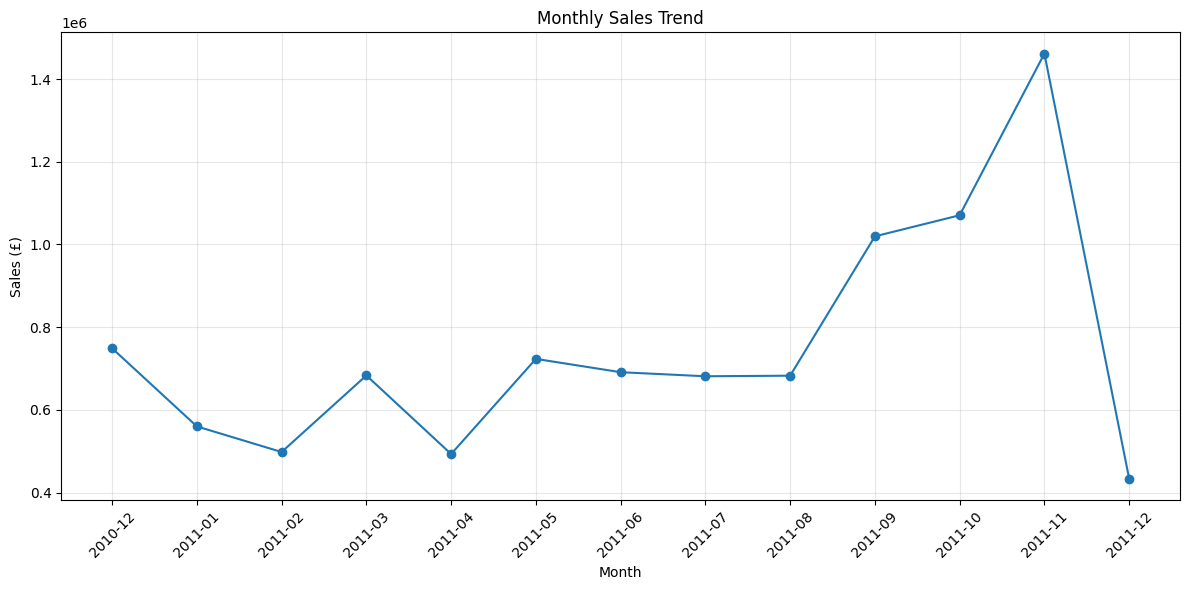

In [ ]:
import matplotlib.pyplot as plt

# Create Month column
df['Month'] = df['InvoiceDate'].dt.to_period('M')

# Calculate monthly Sales
monthly_sales = (
    df.groupby('Month')['Sales']
      .sum()
      .sort_index()
)

# Convert Period to string for plotting
months = monthly_sales.index.astype(str)

# Create the visualization
plt.figure(figsize=(12, 6))

plt.plot(
    months,
    monthly_sales.values,
    marker='o'
)

# Add title and labels
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales (£)')

# Rotate month labels
plt.xticks(rotation=45)

# Add grid
plt.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

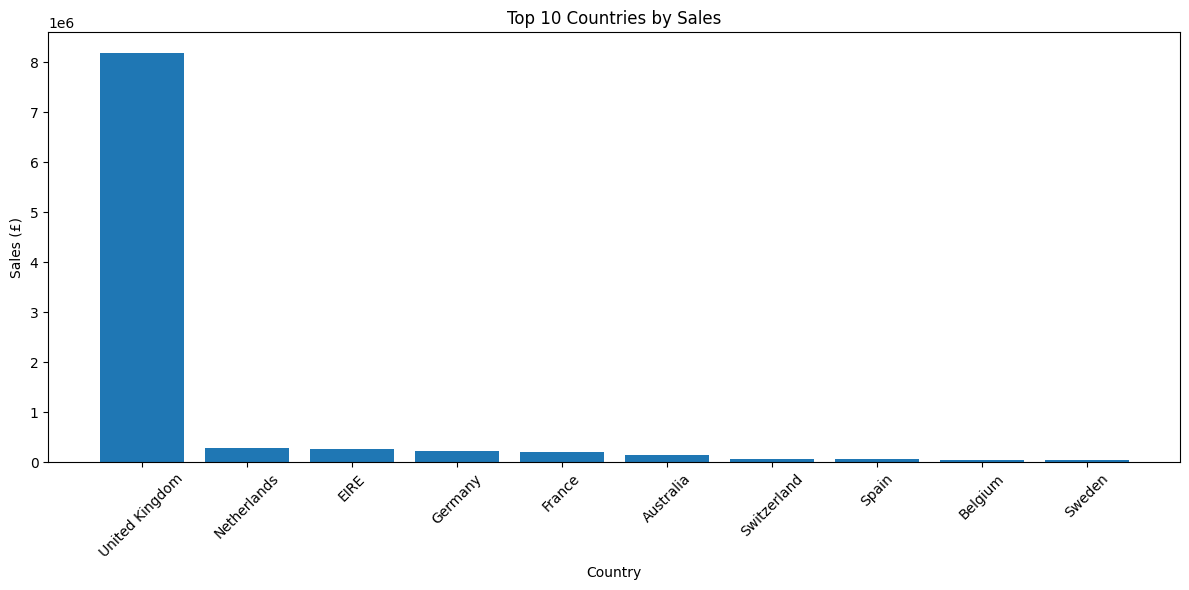

In [ ]:
import matplotlib.pyplot as plt

# Calculate total Sales by Country
country_sales = (
    df.groupby('Country')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Create bar chart
plt.figure(figsize=(12, 6))

plt.bar(
    country_sales.index,
    country_sales.values
)

# Title and labels
plt.title('Top 10 Countries by Sales')
plt.xlabel('Country')
plt.ylabel('Sales (£)')

# Rotate country names
plt.xticks(rotation=45)

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

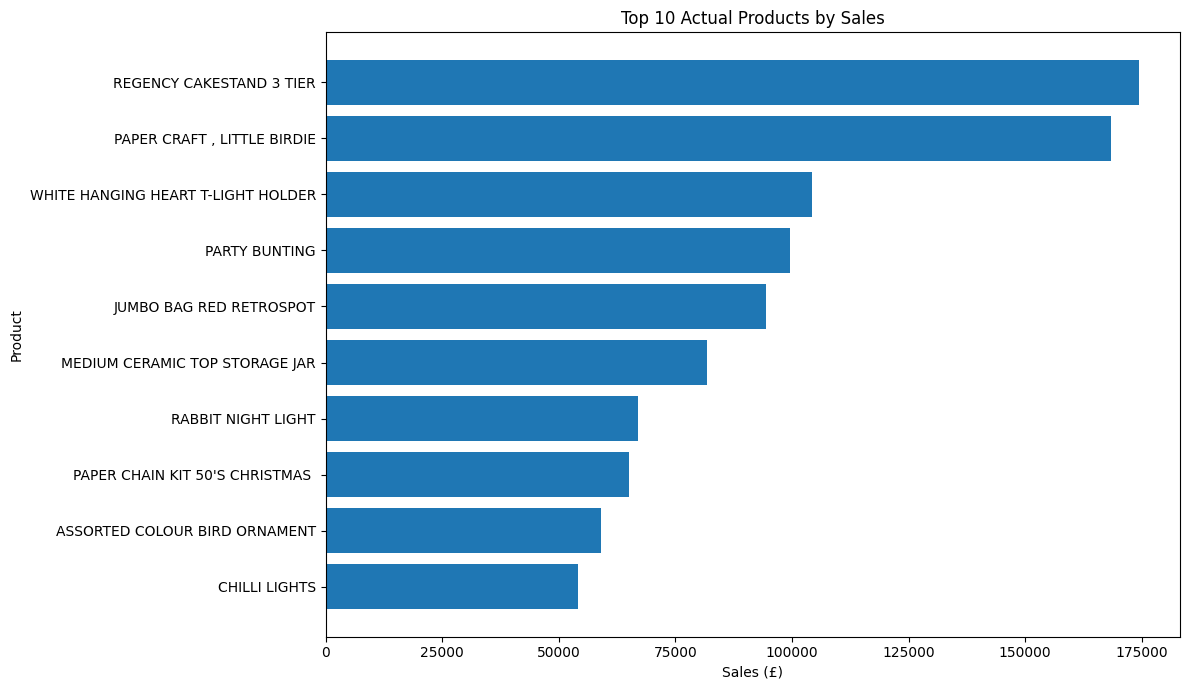

In [ ]:
import matplotlib.pyplot as plt

# Administrative / non-product categories
admin_categories = [
    'AMAZON FEE',
    'POSTAGE',
    'DOTCOM POSTAGE',
    'Manual',
    'CRUK Commission',
    'Bank Charges'
]

# Keep actual product sales only
product_data = df[
    (df['Quantity'] > 0) &
    (~df['Description'].isin(admin_categories))
]

# Calculate Sales by Product
product_sales = (
    product_data
    .groupby(['StockCode', 'Description'])['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Create horizontal bar chart
plt.figure(figsize=(12, 7))

plt.barh(
    product_sales.index.get_level_values('Description'),
    product_sales.values
)

# Highest-selling product at the top
plt.gca().invert_yaxis()

# Titles and labels
plt.title('Top 10 Actual Products by Sales')
plt.xlabel('Sales (£)')
plt.ylabel('Product')

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

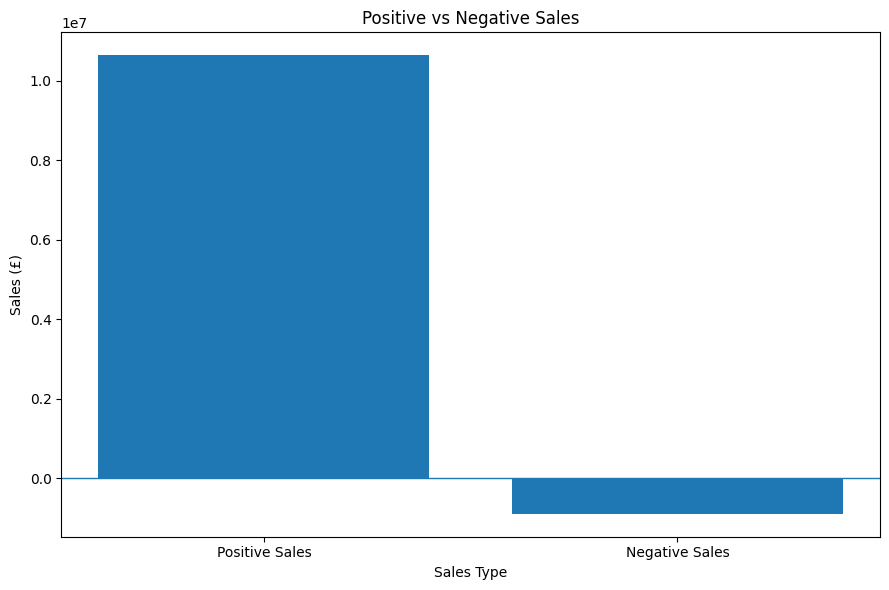

In [ ]:
import matplotlib.pyplot as plt

# Calculate positive Sales
positive_sales = df[df['Quantity'] > 0]['Sales'].sum()

# Calculate negative Sales
negative_sales = df[df['Quantity'] < 0]['Sales'].sum()

# Create labels and values
sales_categories = ['Positive Sales', 'Negative Sales']
sales_values = [positive_sales, negative_sales]

# Create bar chart
plt.figure(figsize=(9, 6))

plt.bar(
    sales_categories,
    sales_values
)

# Title and labels
plt.title('Positive vs Negative Sales')
plt.xlabel('Sales Type')
plt.ylabel('Sales (£)')

# Add horizontal zero line
plt.axhline(0, linewidth=1)

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

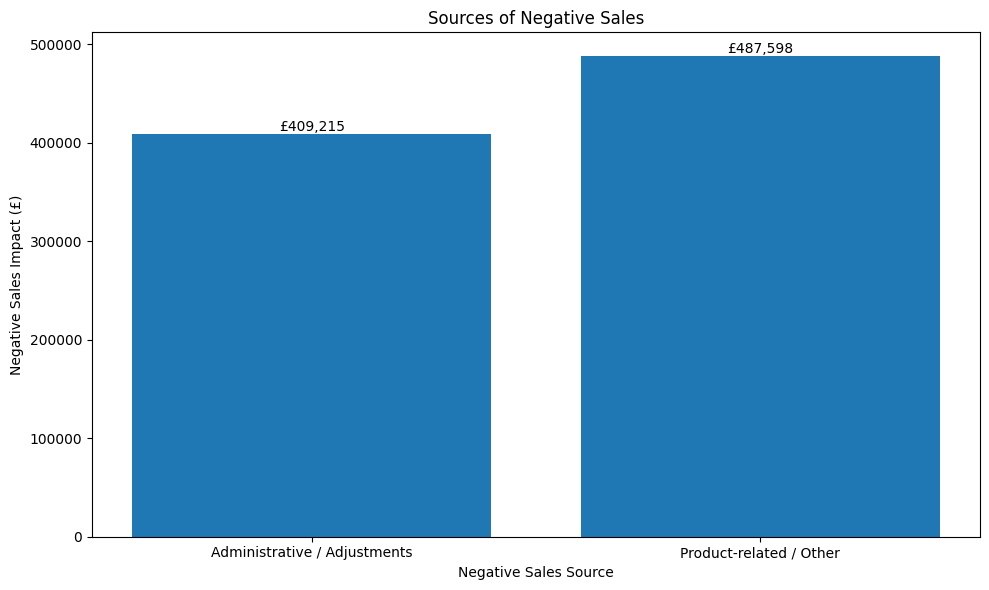

In [ ]:
import matplotlib.pyplot as plt

# Administrative / non-product categories
admin_categories = [
    'AMAZON FEE',
    'POSTAGE',
    'DOTCOM POSTAGE',
    'Manual',
    'CRUK Commission',
    'Bank Charges'
]

# Total negative Sales
total_negative_sales = df[df['Quantity'] < 0]['Sales'].sum()

# Negative Sales from administrative categories
admin_negative_sales = df[
    (df['Quantity'] < 0) &
    (df['Description'].isin(admin_categories))
]['Sales'].sum()

# Negative Sales from remaining categories
product_negative_sales = df[
    (df['Quantity'] < 0) &
    (~df['Description'].isin(admin_categories))
]['Sales'].sum()

# Convert to positive values for easier comparison in the chart
negative_sales_sources = [
    'Administrative / Adjustments',
    'Product-related / Other'
]

negative_sales_values = [
    abs(admin_negative_sales),
    abs(product_negative_sales)
]

# Create bar chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    negative_sales_sources,
    negative_sales_values
)

# Title and labels
plt.title('Sources of Negative Sales')
plt.xlabel('Negative Sales Source')
plt.ylabel('Negative Sales Impact (£)')

# Add values above bars
for bar, value in zip(bars, negative_sales_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'£{value:,.0f}',
        ha='center',
        va='bottom'
    )

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

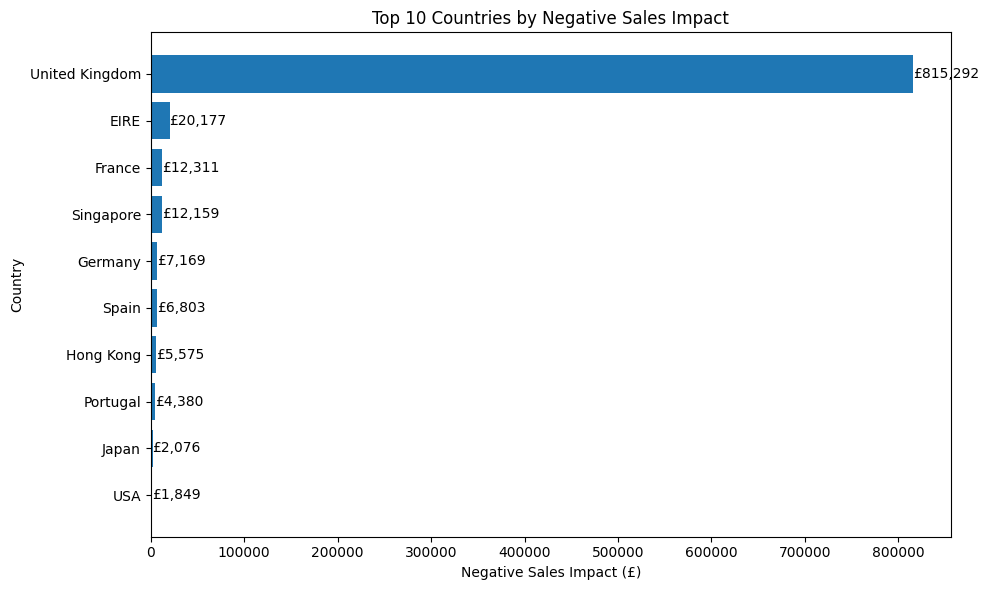

In [ ]:
import matplotlib.pyplot as plt

# Calculate negative Sales by Country
negative_country_sales = (
    df[df['Quantity'] < 0]
    .groupby('Country')['Sales']
    .sum()
    .sort_values()
    .head(10)
)

# Convert negative values to positive for visualization
negative_country_impact = negative_country_sales.abs().sort_values(ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    negative_country_impact.index,
    negative_country_impact.values
)

# Title and labels
plt.title('Top 10 Countries by Negative Sales Impact')
plt.xlabel('Negative Sales Impact (£)')
plt.ylabel('Country')

# Add values to bars
for country, value in zip(
    negative_country_impact.index,
    negative_country_impact.values
):
    plt.text(
        value,
        country,
        f'£{value:,.0f}',
        va='center',
        ha='left'
    )

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

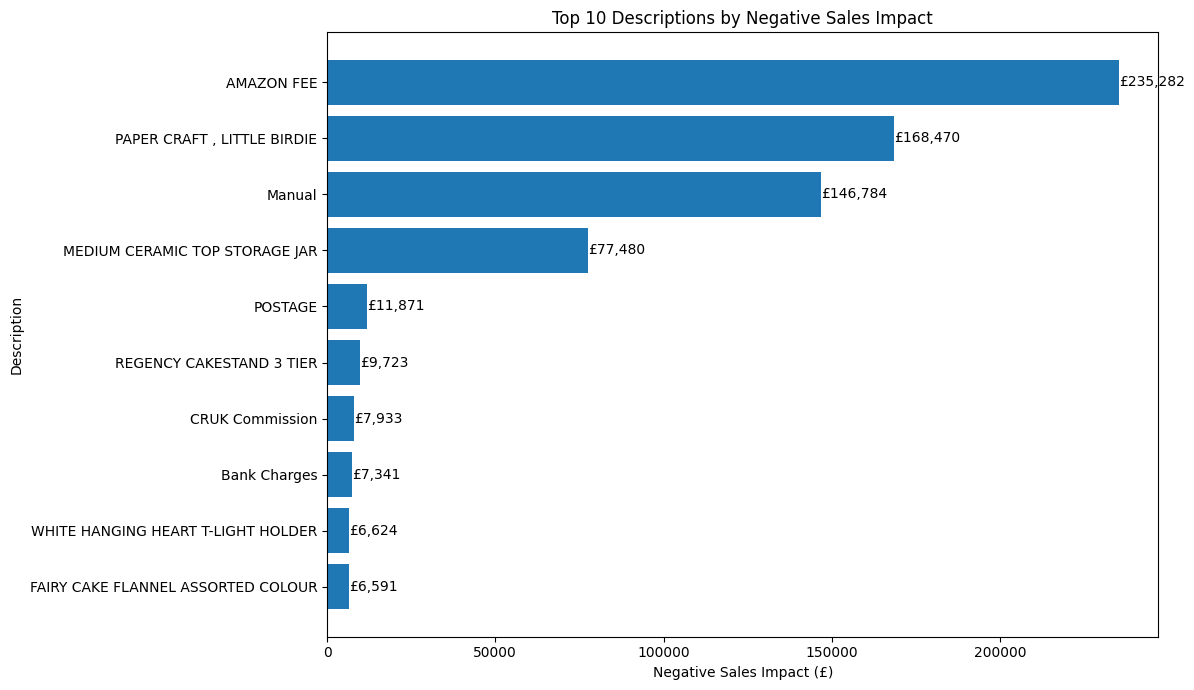

In [ ]:
import matplotlib.pyplot as plt

# Filter negative Sales transactions
negative_sales_data = df[df['Quantity'] < 0]

# Calculate negative Sales by Description
negative_description_sales = (
    negative_sales_data
    .groupby('Description')['Sales']
    .sum()
    .sort_values()
    .head(10)
)

# Convert negative values to positive for visualization
negative_description_impact = (
    negative_description_sales
    .abs()
    .sort_values(ascending=True)
)

# Create horizontal bar chart
plt.figure(figsize=(12, 7))

bars = plt.barh(
    negative_description_impact.index,
    negative_description_impact.values
)

# Title and labels
plt.title('Top 10 Descriptions by Negative Sales Impact')
plt.xlabel('Negative Sales Impact (£)')
plt.ylabel('Description')

# Add values to bars
for bar, value in zip(bars, negative_description_impact.values):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f'£{value:,.0f}',
        va='center',
        ha='left'
    )

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

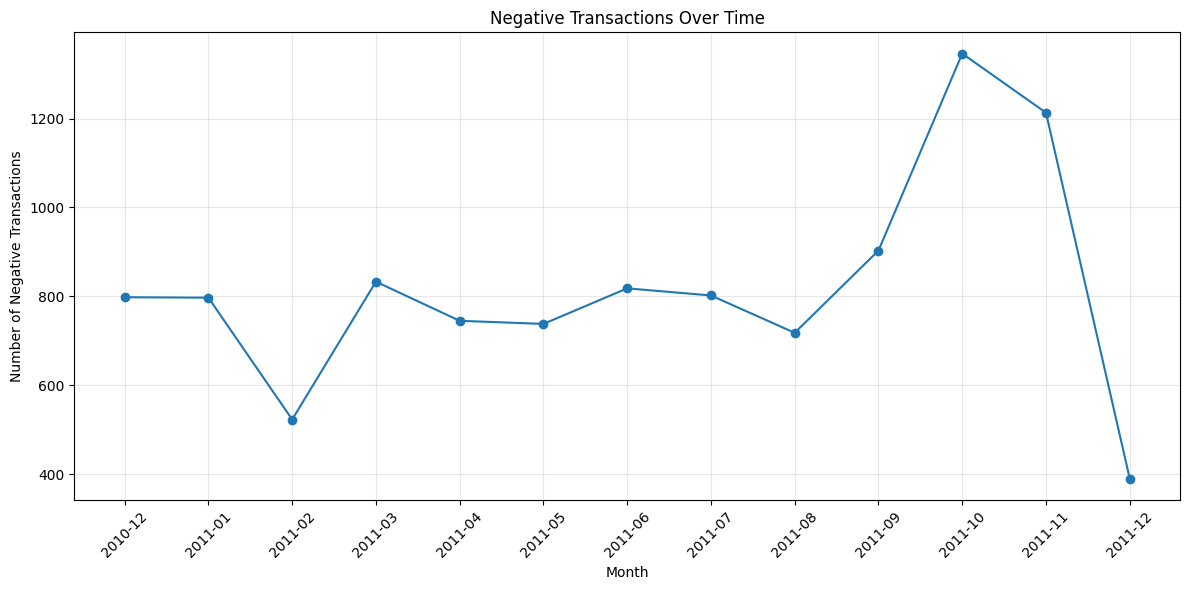

In [ ]:
import matplotlib.pyplot as plt

# Filter negative quantity transactions
negative_transactions = df[df['Quantity'] < 0].copy()

# Create Month column
negative_transactions['Month'] = (
    negative_transactions['InvoiceDate']
    .dt.to_period('M')
)

# Count negative transactions by month
monthly_negative_transactions = (
    negative_transactions
    .groupby('Month')
    .size()
    .sort_index()
)

# Convert months to strings for plotting
months = monthly_negative_transactions.index.astype(str)

# Create line chart
plt.figure(figsize=(12, 6))

plt.plot(
    months,
    monthly_negative_transactions.values,
    marker='o'
)

# Title and labels
plt.title('Negative Transactions Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Negative Transactions')

# Rotate month labels
plt.xticks(rotation=45)

# Add grid
plt.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()

# Display chart
plt.show()